**Theme:**

*“A model that works on fake data is useless.”*

# Imports

In [16]:
import torch 
import torch.nn as nn 


torch.__version__

'2.8.0+cu129'

In [17]:
from torchvision import datasets, transforms 
from torch.utils.data import DataLoader  


In [18]:
import matplotlib.pyplot as plt

# Dataset and Dataloader

## Load MNIST the right way

In [19]:

transform = transforms.ToTensor() 

train_data = datasets.MNIST(
    root='data',
    train=True, 
    download=True, 
    transform=transform
) 

test_data = datasets.MNIST(
    root='data', 
    train=False, 
    download=True, 
    transform=transform 
)

train_loader = DataLoader(train_data, batch_size=64, shuffle=True) 
test_loader = DataLoader(test_data, batch_size=64, shuffle=False) 

## Inspect what actually `DataLoader` do

In [64]:
images, labels = next(iter(train_loader))
print(images.shape) 
print(labels.shape)

torch.Size([64, 1, 28, 28])
torch.Size([64])


- What is the shape of images?

- Why is batch dimension needed?

---

We have 64 black&white (1 channel) images of 28 x 28 pixels

## Visual sanity check

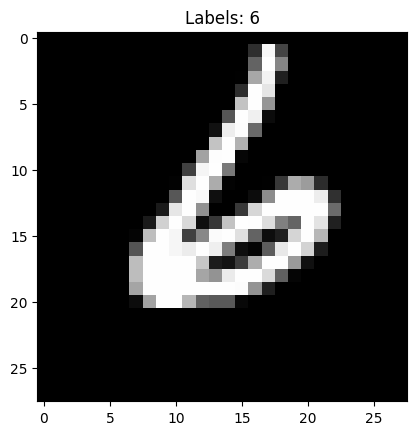

In [65]:
plt.imshow(images[0][0], cmap='gray') 
plt.title(f"Labels: {labels[0]}")
plt.show()

- What does one MNIST image look like?

- Why are they 28×28?

## Understand batching and shuffling

In [27]:
class IndexedDataset(torch.utils.data.Dataset):
    def __init__(self, dataset):
        self.dataset = dataset

    def __getitem__(self, index):
        data, label = self.dataset[index]
        return data, label, index

    def __len__(self):
        return len(self.dataset)

indexed_data = IndexedDataset(train_data)


In [56]:
dataloader = DataLoader(indexed_data, batch_size=10, shuffle=False)

for i, (_, _, idx) in enumerate(dataloader):
    print(f"Shape: {idx.shape[0]},\n Order: {', '.join(map(str,idx.tolist()))}")
    break

Shape: 10,
 Order: 0, 1, 2, 3, 4, 5, 6, 7, 8, 9


  Observe 
  - shape
  - order

In [55]:
dataloader = DataLoader(indexed_data, batch_size=6, shuffle=True, num_workers=0)

for i, (_, _, idx) in enumerate(dataloader):
    print(f"Shape: {idx.shape[0]},\n Order: {', '.join(map(str,idx.tolist()))}")
    break

Shape: 6,
 Order: 16304, 34900, 54309, 3413, 53809, 26203


- Why do we shuffle?

- Why not use full dataset as one batch?

# Interaction

### What happens when the last batch is smaller?


Example:

- Dataset size = 10

- Batch size = 4

- Then DataLoader produces:

| Batch | Samples        |
| ----- | -------------- |
| 1     | 4              |
| 2     | 4              |
| 3     | 2 ← last batch |


This is 100% normal.

PyTorch does NOT drop those 2 samples by default.

It simply gives us:
```python
images.shape = (2, 1, 28, 28)
labels.shape = (2,)
```
Our model and loss function:

- Work with any batch size

- They don’t require it to be fixed

---

### Why this does NOT break training



Look at the training loop:
```python
for images, labels in train_loader:
    preds = model(images)
    loss = loss_fn(preds, labels)
```
Nothing here assumes:

- `Batch size = 64`

- Or any fixed number

The only requirement is:

- First dimension must match between inputs and labels

So `(2, 1, 28, 28)` and `(2,)` works perfectly.

### When do people drop the last batch?



Sometimes we use:

- `DataLoader(..., drop_last=True)`

This drops the final small batch.

Why?

- BatchNorm layers require consistent batch statistics

- Some distributed training setups need equal sizes

But for MNIST and most tasks:

- We should NOT drop the last batch

- We want every data point to be learned.